### Step 1: Loading the Dataset and main statistics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torchinfo import summary
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
from torchmetrics.classification import BinaryAccuracy, BinaryConfusionMatrix, BinaryROC


In [2]:
df = pd.read_csv('./datasets/dataset.csv', index_col=False)

In [3]:
df.head()

,f1,f2,f3,f4,f5,f6,f7,target
0,6,148,72,35,0,33.6,0.627,1
1,1,85,66,29,0,26.6,0.351,0
2,8,183,64,0,0,23.3,0.672,1
3,1,89,66,23,94,28.1,0.167,0
4,0,137,40,35,168,43.1,2.288,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   f1      766 non-null    object
 1   f2      766 non-null    object
 2   f3      766 non-null    int64 
 3   f4      766 non-null    object
 4   f5      766 non-null    object
 5   f6      766 non-null    object
 6   f7      766 non-null    object
 7   target  766 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 48.0+ KB


In [5]:
df.describe()

,f3,target
count,766.000000,766.000000
mean,69.118799,0.349869
std,19.376901,0.477240
min,0.000000,0.000000
25%,62.500000,0.000000
50%,72.000000,0.000000
75%,80.000000,1.000000
max,122.000000,1.000000


In [6]:
object_columns = df.select_dtypes(include=['object'])
for col in object_columns:
    print(col, df[col].unique())

f1 ['6' '1' '8' '0' '5' '3' '10' '2' '4' '7' '9' '11' '13' '15' '17' '12'
 '14' 'c']
f2 ['148' '85' '183' '89' '137' '116' '78' '115' '197' '125' '110' '168'
 '139' '189' '166' '100' '118' '107' '103' '126' '99' '196' '119' '143'
 '147' '97' '145' '117' '109' '158' '88' '92' '122' '138' '102' '90' '111'
 '180' '133' '106' '171' '159' '146' '71' '105' '101' '176' '150' '73'
 '187' '84' '44' '141' '114' '95' '129' '79' '0' '62' '131' '112' '113'
 '74' '83' '136' '80' '123' '81' '134' '142' '144' '93' '163' '151' '96'
 '155' '76' '160' '124' '162' '132' '120' '173' '170' '128' '108' '154'
 '57' '156' '153' '188' '152' '104' '87' '75' '179' '130' '194' '181'
 '135' '184' '140' '177' '164' '91' '165' '86' '193' '191' '161' '167'
 '77' '182' '157' '178' '61' '98' '127' '82' '72' '172' '94' '175' '195'
 '68' '186' '198' '121' '67' '174' '199' '56' '169' '149' '65' '190' 'f']
f4 ['35' '29' '0' '23' '32' '45' '19' '47' '38' '30' '41' '33' '26' '15' '36'
 '11' '31' '37' '42' '25' '18' '24' '39' 

In [7]:
print(len(df[df['f1'] == 'c']))
print(len(df[df['f2'] == 'f']))
print(len(df[df['f4'] == 'a']))
print(len(df[df['f5'] == 'b']))
print(len(df[df['f6'] == 'd']))
print(len(df[df['f7'] == 'e']))

1
1
1
1
1
1


In [8]:
df = df.replace(['a', 'b', 'c', 'd', 'e', 'f'], np.nan)

In [9]:
df = df.dropna()

In [10]:
for col in object_columns:
    print(col, len(df[col].unique()))

f1 17
f2 136
f4 51
f5 184
f6 248
f7 515


In [11]:
df['f2'] = df['f2'].astype('int')
df['f4'] = df['f4'].astype('int')
df['f5'] = df['f5'].astype('int')
df['f6'] = df['f6'].astype('float')
df['f7'] = df['f7'].astype('float')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 760 entries, 0 to 759
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      760 non-null    object 
 1   f2      760 non-null    int64  
 2   f3      760 non-null    int64  
 3   f4      760 non-null    int64  
 4   f5      760 non-null    int64  
 5   f6      760 non-null    float64
 6   f7      760 non-null    float64
 7   target  760 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 53.4+ KB


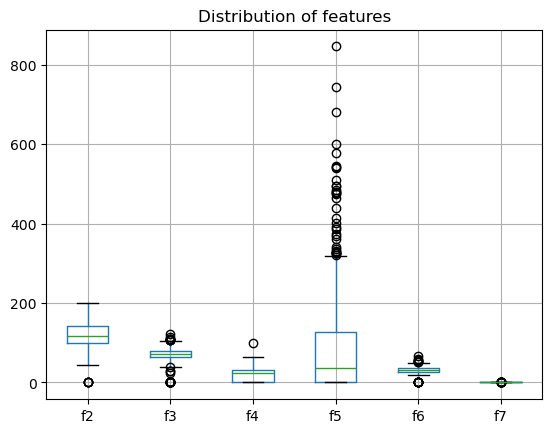

In [12]:
# Creating a boxplot to visualize the distribution of features.
# This shows each feature's spread, median, and potential outliers.
df.boxplot(column=['f2', 'f3', 'f4', 'f5', 'f6', 'f7'])
plt.title('Distribution of features')
plt.show()

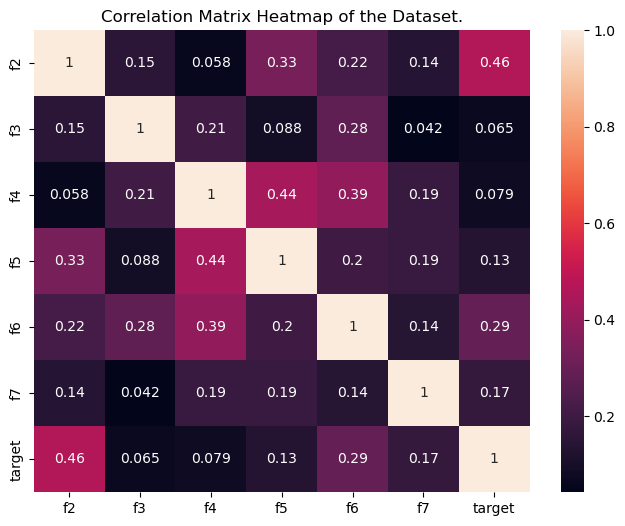

In [13]:
# Visualize the correlations among features and target value
plt.figure(figsize=(8, 6))
ax = plt.axes()
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, ax = ax)
ax.set_title("Correlation Matrix Heatmap of the Dataset.")
plt.show()

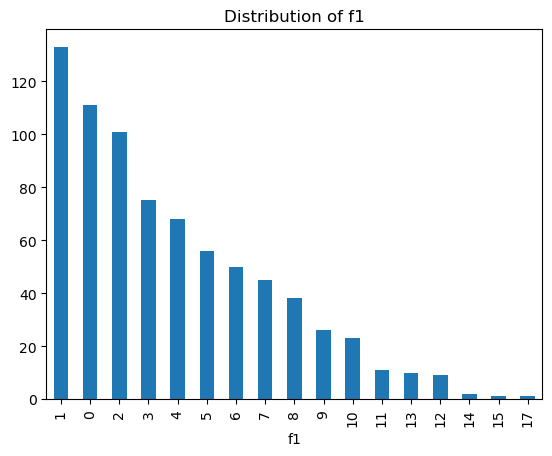

In [14]:
# Distribution of f1
f1_counts = df['f1'].value_counts()
f1_counts.plot(kind='bar')
plt.title('Distribution of f1')
plt.xlabel('f1')
plt.show()

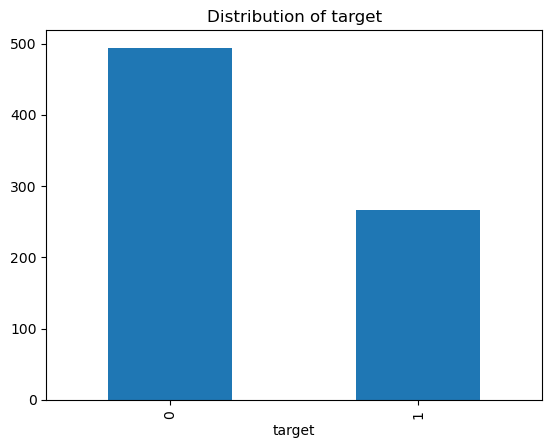

In [15]:
target_counts = df['target'].value_counts()
target_counts.plot(kind='bar')
plt.title('Distribution of target')
plt.xlabel('target')
plt.show()

### Step 2: Preprocessing and Splitting the Dataset

In [16]:
df.describe()

,f2,f3,f4,f5,f6,f7,target
count,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000
mean,120.969737,69.119737,20.507895,80.234211,31.998684,0.473250,0.350000
std,32.023301,19.446088,15.958029,115.581444,7.899724,0.332277,0.477284
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,0.000000
25%,99.000000,63.500000,0.000000,0.000000,27.300000,0.243750,0.000000
50%,117.000000,72.000000,23.000000,36.000000,32.000000,0.375500,0.000000
75%,141.000000,80.000000,32.000000,128.250000,36.600000,0.627500,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,1.000000


In [217]:
df_preprocessed = df.copy()

In [218]:
# Convert categorical variables to numerical variables using one-hot encoding
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_feature = enc.fit_transform(df_preprocessed[['f1']])

In [219]:
df_encoded = pd.DataFrame(encoded_feature, columns=enc.get_feature_names_out(['f1']))
df_preprocessed = df_preprocessed.drop('f1', axis=1)
df_preprocessed = pd.concat([df_preprocessed, df_encoded], axis=1)

In [220]:
# Split the dataset into training, testing and validation sets.
df_shuffled = df_preprocessed.sample(frac=1).reset_index(drop=True)

X = df_shuffled.drop(columns=['target'])
y = df_shuffled['target']

In [221]:
# Oversampling
ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)

In [222]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.1 , random_state=7)

In [223]:
print(y_train.value_counts())
print(y_test.value_counts())

target
1    446
0    443
Name: count, dtype: int64
target
0    51
1    48
Name: count, dtype: int64


In [224]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.11, random_state=7)

In [225]:
print(y_train.value_counts())
print(y_val.value_counts())

target
0    398
1    393
Name: count, dtype: int64
target
1    53
0    45
Name: count, dtype: int64


In [226]:
# Scale numerical variables
scaler = StandardScaler()
scaler.fit(X_train[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])

StandardScaler()

In [227]:
X_train[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']] = scaler.transform(X_train[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])
X_val[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']] = scaler.transform(X_val[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])
X_test[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']] = scaler.transform(X_test[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])

In [228]:
# convert the DataFrame to PyTorch tensor
X_train = torch.tensor(X_train.values, dtype=torch.float32)
X_val = torch.tensor(X_val.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

### Step 3: Defining the Neural Network

- Input neurons: 23
- Output neurons: 1
- Activation function used for the hidden layers: ELU
- Activation function used for the output layer: Sigmoid
- The number of hidden layers: 2
- The size of each hidden layer: 64, 128
- Dropout: 0.3

In [229]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.elu1 = nn.ELU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, 128)
        self.elu2 = nn.ELU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.elu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.elu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        output = self.sigmoid(x)
        return output



### Step 4: Training the Neural Network

In [235]:
net = Net()
summary(net)

Layer (type:depth-idx)                   Param #
Net                                      --
├─Linear: 1-1                            1,536
├─ELU: 1-2                               --
├─Dropout: 1-3                           --
├─Linear: 1-4                            8,320
├─ELU: 1-5                               --
├─Dropout: 1-6                           --
├─Linear: 1-7                            129
├─Sigmoid: 1-8                           --
Total params: 9,985
Trainable params: 9,985
Non-trainable params: 0

In [236]:
loss_function = nn.BCELoss()
optimizer = optim.SGD(net.parameters(), lr=0.001)

In [237]:
train_dataset = TensorDataset(X_train, y_train.view(-1, 1))
val_dataset = TensorDataset(X_val, y_val.view(-1, 1))
train_loader = DataLoader(train_dataset, batch_size=4)
val_loader = DataLoader(val_dataset, batch_size=4)
train_accuracy_metric = BinaryAccuracy()
val_accuracy_metric = BinaryAccuracy()
train_accuracy_hist = []
val_accuracy_hist = []
train_loss_hist = []
val_loss_hist = []

best_loss = float('inf')
PATH = "heejuhwa_assignment1_part1.pt"
start_time = time.time()
for epoch in range(10):
    net.train()
    train_loss = 0.0
    # train
    for train_inputs, train_labels in train_loader:
        optimizer.zero_grad()
        outputs = net(train_inputs)
        predicted = torch.round(outputs)
        train_accuracy_metric.update(predicted, train_labels)
        loss = loss_function(outputs, train_labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_accuracy_hist.append(train_accuracy_metric.compute().item())
    train_loss_hist.append(train_loss/len(train_loader))

    # validation
    net.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_outputs = net(val_inputs)
            val_predicted = torch.round(val_outputs)
            val_accuracy_metric.update(val_predicted, val_labels)
            val_loss += loss_function(val_outputs, val_labels).item()
    val_accuracy_hist.append(val_accuracy_metric.compute().item())
    val_loss_hist.append(val_loss/len(val_loader))

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(net.state_dict(), PATH)

    print(f"Epoch {epoch+1}, Training Loss: {train_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(val_loader):.4f}")
training_time = time.time() - start_time
print(f"Training Time: {training_time}")

Epoch 1, Training Loss: 0.6998, Validation Loss: 0.6967
Epoch 2, Training Loss: 0.6858, Validation Loss: 0.6831
Epoch 3, Training Loss: 0.6728, Validation Loss: 0.6706
Epoch 4, Training Loss: 0.6634, Validation Loss: 0.6596
Epoch 5, Training Loss: 0.6492, Validation Loss: 0.6488
Epoch 6, Training Loss: 0.6424, Validation Loss: 0.6389
Epoch 7, Training Loss: 0.6321, Validation Loss: 0.6295
Epoch 8, Training Loss: 0.6195, Validation Loss: 0.6202
Epoch 9, Training Loss: 0.6143, Validation Loss: 0.6113
Epoch 10, Training Loss: 0.6092, Validation Loss: 0.6032
Training Time: 0.7367229461669922


In [259]:
def test_model(model, test_loader):
    model.eval()
    all_labels = torch.tensor([])
    all_outputs = torch.tensor([])
    all_preds = torch.tensor([])
    bcm = BinaryConfusionMatrix()
    broc = BinaryROC(thresholds=5)
    test_loss = 0.0

    with torch.no_grad():
        for test_inputs, test_labels in test_loader:
            test_outputs = model(test_inputs)
            test_predicted = torch.round(test_outputs)

            loss = loss_function(test_outputs, test_labels)
            test_loss += loss.item()
            all_labels = torch.cat((all_labels, test_labels), dim=0)
            all_preds = torch.cat((all_preds, test_predicted), dim=0)
            all_outputs = torch.cat((all_outputs, test_outputs), dim=0)

    metric = bcm(all_preds, all_labels)
    tn = metric[0, 0].item()
    fp = metric[0, 1].item()
    fn = metric[1, 0].item()
    tp = metric[1, 1].item()
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    # fpr, tpr, thresholds = broc(all_preds, all_labels)

    # Print the results
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {2 * (precision * recall) / (precision + recall):.4f}')
    print(f'Test Loss: {test_loss / len(test_loader):.4f}')

    return accuracy, test_loss / len(test_loader), metric, all_outputs, all_labels

In [260]:
test_net = Net()
test_net.load_state_dict(torch.load(PATH, weights_only=True))
test_dataset = TensorDataset(X_test, y_test.view(-1, 1))
test_loader = DataLoader(test_dataset, batch_size=4)
test_accuracy, test_loss, metric, preds, labels = test_model(test_net, test_loader)

Accuracy: 0.7980
Precision: 0.8333
Recall: 0.7292
F1 Score: 0.7778
Test Loss: 0.5786


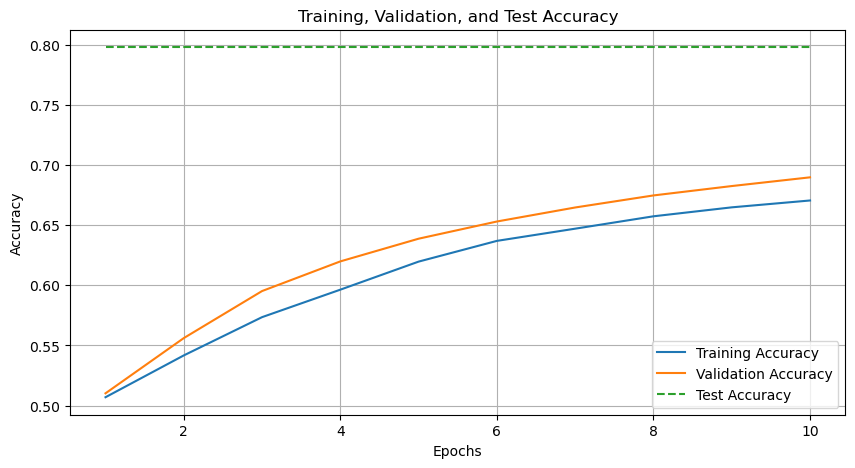

In [240]:
# Plot accuracies
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), train_accuracy_hist, label='Training Accuracy')
plt.plot(range(1, 11), val_accuracy_hist, label='Validation Accuracy')
plt.plot(range(1, 11), [test_accuracy] * 10, label='Test Accuracy', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training, Validation, and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

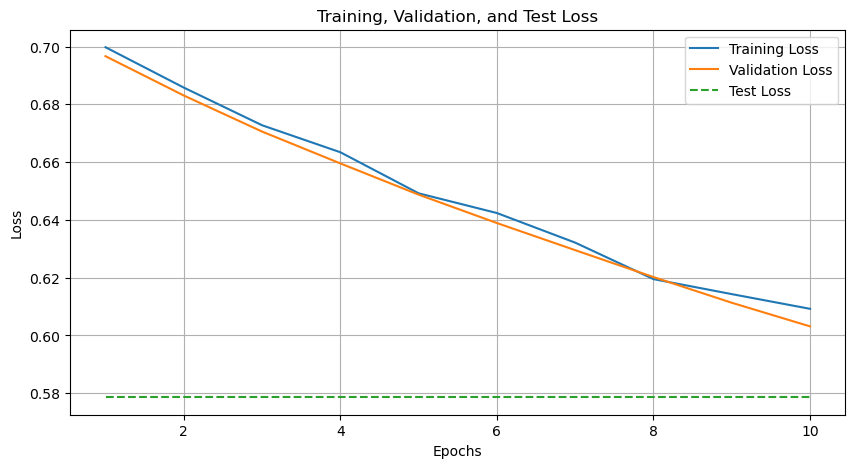

In [241]:
# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), train_loss_hist, label='Training Loss')
plt.plot(range(1, 11), val_loss_hist, label='Validation Loss')
plt.plot(range(1,11), [test_loss] * 10, label='Test Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training, Validation, and Test Loss')
plt.legend()
plt.grid(True)
plt.show()

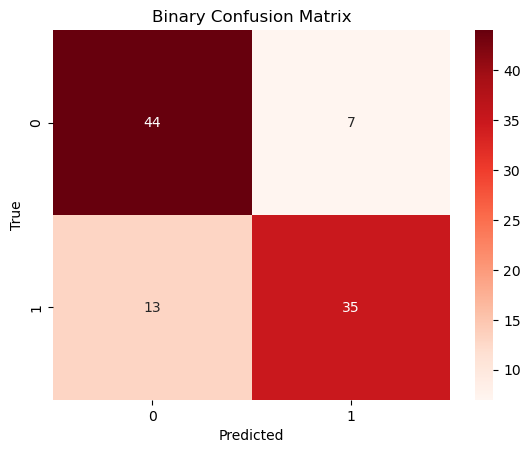

In [261]:
sns.heatmap(metric.numpy(), annot=True, fmt="d", cmap="Reds", xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Binary Confusion Matrix')
plt.show()

In [266]:
# ROC curve
roc = BinaryROC()
fpr, tpr, thresholds = roc(preds, labels.to(dtype=torch.long))

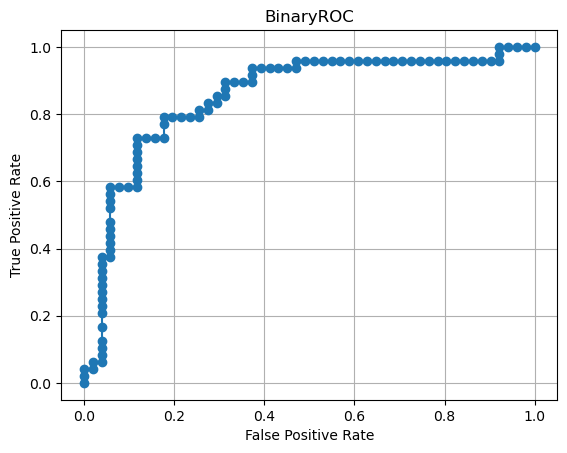

In [267]:
plt.plot(fpr, tpr, marker='o')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BinaryROC')
plt.grid()
plt.show()

In [268]:
df_preprocessed.to_csv('./df_preprocessed.csv', index=False)

### Reference
- Assignment 1 data preprocessing, plot
- Quiz 5 PyTorch
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html
- https://scikit-learn.org/1.5/modules/preprocessing.html
- https://scikit-learn.org/dev/modules/generated/sklearn.preprocessing.StandardScaler.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- https://pytorch.org/docs/stable/nn.html
- https://pytorch.org/tutorials/recipes/recipes/defining_a_neural_network.html
- https://docs.python.org/3/library/time.html
- https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html
- https://lightning.ai/docs/torchmetrics/stable/classification/roc.html